# Week 2 Lab: Dynamic Programming
**MSDS684 - Reinforcement Learning**

Implement policy iteration and value iteration to solve GridWorld.

## Conda Environment Setup (Miniconda)

Run the following commands in your terminal to create and activate a conda environment for this lab:

```bash
# Create a new conda environment
conda create -n rl-lab2 python=3.11 -y

# Activate the environment
conda activate rl-lab2

# Install required packages
conda install numpy matplotlib -y
pip install gymnasium

# Register the environment as a Jupyter kernel
pip install ipykernel
python -m ipykernel install --user --name rl-lab2 --display-name "Python (rl-lab2)"
```

After setup, select the **"Python (rl-lab2)"** kernel in this notebook.

## Setup & Imports
- Import NumPy, Matplotlib, Gymnasium
- Set random seeds for reproducibility

In [67]:
%pip install -r requirements.txt -q

Note: you may need to restart the kernel to use updated packages.


In [68]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import gymnasium as gym
import time
from typing import Optional

np.random.seed(42)

%matplotlib inline
plt.rcParams['figure.figsize'] = (8, 6)
plt.rcParams['font.size'] = 12

## Custom GridWorld Environment
Build a custom GridWorld (4x4 or larger) following Gymnasium's API.

### Requirements:
- Configurable rewards, obstacles, and terminal states
- Support for **deterministic** transitions
- Support for **stochastic** transitions (e.g., 80% intended direction, 10% each perpendicular)
- Expose full transition model `P(s', r | s, a)` for DP access
- Implement `env.unwrapped` style access to transition dynamics

In [69]:
class GridWorldEnv(gym.Env):
    """
    Custom GridWorld environment following Gymnasium's API.
    Exposes full transition model P[s][a] for dynamic programming.
    """

    metadata = {"render_modes": ["human"]}

    # Actions: 0=up, 1=right, 2=down, 3=left
    ACTION_UP = 0
    ACTION_RIGHT = 1
    ACTION_DOWN = 2
    ACTION_LEFT = 3

    # Direction vectors (row_delta, col_delta) for each action
    ACTION_DELTAS = {
        0: (-1, 0),  # up
        1: (0, 1),   # right
        2: (1, 0),   # down
        3: (0, -1),  # left
    }

    # Perpendicular actions for stochastic transitions
    PERPENDICULAR = {
        0: [3, 1],  # up -> [left, right]
        1: [0, 2],  # right -> [up, down]
        2: [1, 3],  # down -> [right, left]
        3: [2, 0],  # left -> [down, up]
    }

    def __init__(
        self,
        grid_size: tuple = (4, 4),
        start: tuple = (0, 0),
        goals: Optional[list] = None,
        obstacles: Optional[list] = None,
        step_reward: float = -1.0,
        goal_reward: float = 0.0,
        obstacle_reward: float = -10.0,
        slip_prob: float = 0.0,
        gamma: float = 1.0,
        render_mode: Optional[str] = None,
    ):
        super().__init__()

        self.nrow, self.ncol = grid_size
        self.n_states = self.nrow * self.ncol
        self.start = start
        self.goals = goals if goals is not None else [(self.nrow - 1, self.ncol - 1)]
        self.obstacles = obstacles if obstacles is not None else []
        self.step_reward = step_reward
        self.goal_reward = goal_reward
        self.obstacle_reward = obstacle_reward
        self.slip_prob = slip_prob  # 0.0 = deterministic, e.g. 0.1 for 80/10/10
        self.gamma = gamma
        self.render_mode = render_mode

        self.observation_space = gym.spaces.Discrete(self.n_states)
        self.action_space = gym.spaces.Discrete(4)

        # Build the full transition model
        self.P = self._build_transition_model()

    def _pos_to_state(self, row, col):
        return row * self.ncol + col

    def _state_to_pos(self, state):
        return divmod(state, self.ncol)

    def _is_valid(self, row, col):
        return 0 <= row < self.nrow and 0 <= col < self.ncol

    def _get_next_state_and_reward(self, row, col, action):
        """Given a position and action, return (next_state, reward, terminated)."""
        # Terminal states are absorbing — no transitions out
        if (row, col) in self.goals:
            s = self._pos_to_state(row, col)
            return s, 0.0, True

        dr, dc = self.ACTION_DELTAS[action]
        new_row, new_col = row + dr, col + dc

        # Boundary check: stay in place if invalid or obstacle
        if not self._is_valid(new_row, new_col) or (new_row, new_col) in self.obstacles:
            new_row, new_col = row, col

        next_state = self._pos_to_state(new_row, new_col)
        terminated = (new_row, new_col) in self.goals

        if terminated:
            reward = self.goal_reward
        elif (new_row, new_col) in self.obstacles:
            reward = self.obstacle_reward
        else:
            reward = self.step_reward

        return next_state, reward, terminated

    def _build_transition_model(self):
        """Build P[s][a] = [(prob, next_state, reward, terminated), ...]"""
        P = {}
        for s in range(self.n_states):
            P[s] = {}
            row, col = self._state_to_pos(s)

            for a in range(4):
                transitions = []

                if self.slip_prob == 0.0:
                    # Deterministic
                    ns, r, done = self._get_next_state_and_reward(row, col, a)
                    transitions.append((1.0, ns, r, done))
                else:
                    # Stochastic: intended direction + perpendicular slips
                    intended_prob = 1.0 - 2 * self.slip_prob

                    # Intended direction
                    ns, r, done = self._get_next_state_and_reward(row, col, a)
                    transitions.append((intended_prob, ns, r, done))

                    # Perpendicular directions
                    for perp_action in self.PERPENDICULAR[a]:
                        ns, r, done = self._get_next_state_and_reward(row, col, perp_action)
                        transitions.append((self.slip_prob, ns, r, done))

                P[s][a] = transitions

        return P

    def reset(self, seed=None, options=None):
        super().reset(seed=seed)
        self.current_state = self._pos_to_state(*self.start)
        return self.current_state, {}

    def step(self, action):
        row, col = self._state_to_pos(self.current_state)

        if self.slip_prob == 0.0:
            actual_action = action
        else:
            probs = [1.0 - 2 * self.slip_prob, self.slip_prob, self.slip_prob]
            actions = [action] + self.PERPENDICULAR[action]
            actual_action = self.np_random.choice(actions, p=probs)

        next_state, reward, terminated = self._get_next_state_and_reward(row, col, actual_action)
        self.current_state = next_state

        return next_state, reward, terminated, False, {}

    def render(self):
        row, col = self._state_to_pos(self.current_state)
        grid = np.full((self.nrow, self.ncol), ".", dtype=object)
        for r, c in self.obstacles:
            grid[r, c] = "X"
        for r, c in self.goals:
            grid[r, c] = "G"
        grid[row, col] = "A"
        print("\n".join(" ".join(r) for r in grid))
        print()

## Visualization Helpers
Create reusable plotting functions before implementing algorithms.

### Functions needed:
- **Value function heatmap** — display V(s) as a colored grid using Matplotlib `imshow`
- **Policy arrow plot** — display π(s) as arrows using `quiver`
- **Convergence curves** — plot iterations vs. delta and wall-clock time

In [70]:
def plot_value_function(V, env, ax=None, title="Value Function"):
    """Plot V(s) as a heatmap over the grid."""
    if ax is None:
        fig, ax = plt.subplots(1, 1, figsize=(6, 5))

    grid = V.reshape(env.nrow, env.ncol).copy()

    # Mask obstacles for distinct coloring
    masked_grid = np.ma.array(grid)
    for r, c in env.obstacles:
        masked_grid[r, c] = np.ma.masked

    im = ax.imshow(masked_grid, cmap="coolwarm", interpolation="nearest")
    plt.colorbar(im, ax=ax, shrink=0.8)

    # Annotate each cell with its value
    for s in range(env.n_states):
        r, c = env._state_to_pos(s)
        if (r, c) in env.obstacles:
            ax.text(c, r, "X", ha="center", va="center", fontsize=14, fontweight="bold", color="black")
        elif (r, c) in env.goals:
            ax.text(c, r, f"G\n{V[s]:.1f}", ha="center", va="center", fontsize=10, fontweight="bold", color="white")
        else:
            ax.text(c, r, f"{V[s]:.1f}", ha="center", va="center", fontsize=10)

    ax.set_xticks(range(env.ncol))
    ax.set_yticks(range(env.nrow))
    ax.set_title(title)
    return ax


# Action-to-arrow mapping in plot coordinates (col_delta, -row_delta)
ARROW_DIRS = {
    0: (0, -1),   # up: negative y in plot
    1: (1, 0),    # right: positive x
    2: (0, 1),    # down: positive y in plot
    3: (-1, 0),   # left: negative x
}

ACTION_SYMBOLS = {0: "\u2191", 1: "\u2192", 2: "\u2193", 3: "\u2190"}  # ↑ → ↓ ←


def plot_policy(policy, env, ax=None, title="Policy"):
    """Plot policy as arrows on the grid using quiver."""
    if ax is None:
        fig, ax = plt.subplots(1, 1, figsize=(6, 5))

    # Background grid
    bg = np.ones((env.nrow, env.ncol)) * 0.9
    for r, c in env.obstacles:
        bg[r, c] = 0.3
    for r, c in env.goals:
        bg[r, c] = 0.6
    ax.imshow(bg, cmap="gray", vmin=0, vmax=1, interpolation="nearest")

    # Draw arrows for non-terminal, non-obstacle states
    X, Y, U, V_arr = [], [], [], []
    for s in range(env.n_states):
        r, c = env._state_to_pos(s)
        if (r, c) in env.goals or (r, c) in env.obstacles:
            continue
        a = policy[s]
        dx, dy = ARROW_DIRS[a]
        X.append(c)
        Y.append(r)
        U.append(dx)
        V_arr.append(dy)

    ax.quiver(X, Y, U, V_arr, angles="xy", scale_units="xy", scale=2.5,
              color="dodgerblue", width=0.02, headwidth=4)

    # Label goals and obstacles
    for r, c in env.goals:
        ax.text(c, r, "G", ha="center", va="center", fontsize=14, fontweight="bold", color="green")
    for r, c in env.obstacles:
        ax.text(c, r, "X", ha="center", va="center", fontsize=14, fontweight="bold", color="red")

    ax.set_xticks(range(env.ncol))
    ax.set_yticks(range(env.nrow))
    ax.set_title(title)
    ax.set_xlim(-0.5, env.ncol - 0.5)
    ax.set_ylim(env.nrow - 0.5, -0.5)
    return ax


def plot_convergence(results, title="Convergence Comparison"):
    """
    Plot convergence curves for one or more algorithms.

    results: dict of {name: {"deltas": [...], "times": [...]}}
    """
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

    for name, data in results.items():
        iterations = range(1, len(data["deltas"]) + 1)
        ax1.plot(iterations, data["deltas"], label=name, marker=".", markersize=3)
        ax2.plot(iterations, data["times"], label=name, marker=".", markersize=3)

    ax1.set_yscale("log")
    ax1.set_xlabel("Iteration")
    ax1.set_ylabel("Max Value Change (delta)")
    ax1.set_title("Convergence by Iteration")
    ax1.legend()
    ax1.grid(True, alpha=0.3)

    ax2.set_xlabel("Iteration")
    ax2.set_ylabel("Cumulative Time (s)")
    ax2.set_title("Wall-Clock Time")
    ax2.legend()
    ax2.grid(True, alpha=0.3)

    fig.suptitle(title, fontsize=14)
    plt.tight_layout()
    return fig


def plot_value_and_policy(V, policy, env, title=""):
    """Combined view: value heatmap + policy arrows side by side."""
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5))
    plot_value_function(V, env, ax=ax1, title=f"{title} — Value Function")
    plot_policy(policy, env, ax=ax2, title=f"{title} — Policy")
    plt.tight_layout()
    return fig

## Policy Evaluation (Prediction Problem)
Compute V(s) for a given policy π.

### Synchronous Policy Evaluation
- Use a separate array for V_new; update all states before copying back
- Sweep over all states: $V_{k+1}(s) = \sum_a \pi(a|s) \sum_{s',r} p(s',r|s,a)[r + \gamma V_k(s')]$
- Track delta (max change) per iteration for convergence check

In [71]:
def policy_evaluation_sync(policy, env, gamma=1.0, theta=1e-8, max_iterations=10000):
    """
    Synchronous policy evaluation.
    Uses separate V_old and V_new arrays — all states see the same generation.
    """
    n_states = env.n_states
    V = np.zeros(n_states)
    deltas = []
    times = []
    start_time = time.time()

    for i in range(max_iterations):
        V_new = np.zeros(n_states)
        delta = 0.0

        for s in range(n_states):
            a = policy[s]
            v_new = 0.0
            for prob, next_state, reward, done in env.P[s][a]:
                v_new += prob * (reward + gamma * V[next_state])
            V_new[s] = v_new
            delta = max(delta, abs(V[s] - v_new))

        V = V_new
        deltas.append(delta)
        times.append(time.time() - start_time)

        if delta < theta:
            break

    return V, {"deltas": deltas, "times": times}

### In-Place Policy Evaluation
- Update V(s) in-place as we sweep (no separate V_new array)
- Typically converges faster since updates use latest values immediately

In [72]:
def policy_evaluation_inplace(policy, env, gamma=1.0, theta=1e-8, max_iterations=10000):
    """
    In-place policy evaluation.
    Updates V(s) immediately — later states in the sweep see earlier updates.
    """
    n_states = env.n_states
    V = np.zeros(n_states)
    deltas = []
    times = []
    start_time = time.time()

    for i in range(max_iterations):
        delta = 0.0

        for s in range(n_states):
            a = policy[s]
            v_old = V[s]
            v_new = 0.0
            for prob, next_state, reward, done in env.P[s][a]:
                v_new += prob * (reward + gamma * V[next_state])
            V[s] = v_new
            delta = max(delta, abs(v_old - v_new))

        deltas.append(delta)
        times.append(time.time() - start_time)

        if delta < theta:
            break

    return V, {"deltas": deltas, "times": times}

## Policy Improvement
Given V(s), produce a greedy policy.

- For each state, compute Q(s,a) for all actions
- $\pi'(s) = \arg\max_a \sum_{s',r} p(s',r|s,a)[r + \gamma V(s')]$
- Track whether policy changed (policy_stable flag)

In [73]:
def policy_improvement(V, policy, env, gamma=1.0):
    """
    Given V(s) and current policy, compute the greedy policy.
    Returns (new_policy, policy_stable).
    """
    n_states = env.n_states
    n_actions = env.action_space.n
    new_policy = np.zeros(n_states, dtype=int)
    policy_stable = True

    for s in range(n_states):
        q_values = np.zeros(n_actions)
        for a in range(n_actions):
            for prob, next_state, reward, done in env.P[s][a]:
                q_values[a] += prob * (reward + gamma * V[next_state])

        best_action = np.argmax(q_values)
        new_policy[s] = best_action

        if best_action != policy[s]:
            policy_stable = False

    return new_policy, policy_stable

## Policy Iteration
Alternate between evaluation and improvement until policy is stable.

### Synchronous Policy Iteration
- Initialize policy arbitrarily
- **Evaluate**: run synchronous policy evaluation to convergence
- **Improve**: derive greedy policy from V(s)
- If policy unchanged → done; else repeat
- Record V(s) and π(s) at each outer iteration for visualization

In [74]:
def policy_iteration_sync(env, gamma=1.0, theta=1e-8):
    """
    Policy iteration using synchronous policy evaluation.
    Returns (V, policy, history).
    """
    n_states = env.n_states
    policy = np.zeros(n_states, dtype=int)
    history: dict = {
        "v_snapshots": [],
        "policy_snapshots": [],
        "eval_sweeps": [],
        "deltas": [],
        "times": [],
        "total_time": 0.0,
    }
    start_time = time.time()

    while True:
        # Evaluate
        V, eval_info = policy_evaluation_sync(policy, env, gamma=gamma, theta=theta)
        history["eval_sweeps"].append(len(eval_info["deltas"]))
        history["deltas"].extend(eval_info["deltas"])
        history["times"].extend([t + (time.time() - start_time - eval_info["times"][-1]) for t in eval_info["times"]])

        # Snapshot
        history["v_snapshots"].append(V.copy())
        history["policy_snapshots"].append(policy.copy())

        # Improve
        new_policy, stable = policy_improvement(V, policy, env, gamma=gamma)
        policy = new_policy

        if stable:
            break

    # Final snapshot after last improvement
    history["v_snapshots"].append(V.copy())
    history["policy_snapshots"].append(policy.copy())
    history["total_time"] = time.time() - start_time

    return V, policy, history

### In-Place Policy Iteration
- Same loop, but use in-place policy evaluation in the inner loop

In [75]:
def policy_iteration_inplace(env, gamma=1.0, theta=1e-8):
    """
    Policy iteration using in-place policy evaluation.
    Returns (V, policy, history).
    """
    n_states = env.n_states
    policy = np.zeros(n_states, dtype=int)
    history: dict = {
        "v_snapshots": [],
        "policy_snapshots": [],
        "eval_sweeps": [],
        "deltas": [],
        "times": [],
        "total_time": 0.0,
    }
    start_time = time.time()

    while True:
        # Evaluate
        V, eval_info = policy_evaluation_inplace(policy, env, gamma=gamma, theta=theta)
        history["eval_sweeps"].append(len(eval_info["deltas"]))
        history["deltas"].extend(eval_info["deltas"])
        history["times"].extend([t + (time.time() - start_time - eval_info["times"][-1]) for t in eval_info["times"]])

        # Snapshot
        history["v_snapshots"].append(V.copy())
        history["policy_snapshots"].append(policy.copy())

        # Improve
        new_policy, stable = policy_improvement(V, policy, env, gamma=gamma)
        policy = new_policy

        if stable:
            break

    # Final snapshot after last improvement
    history["v_snapshots"].append(V.copy())
    history["policy_snapshots"].append(policy.copy())
    history["total_time"] = time.time() - start_time

    return V, policy, history

## Value Iteration
Combine truncated evaluation (1 sweep) with improvement in a single update.

### Synchronous Value Iteration
- $V_{k+1}(s) = \max_a \sum_{s',r} p(s',r|s,a)[r + \gamma V_k(s')]$
- Use separate V_new array per sweep
- Converge when delta < θ, then extract greedy policy

In [76]:
def value_iteration_sync(env, gamma=1.0, theta=1e-8, max_iterations=10000):
    """
    Synchronous value iteration.
    Each sweep: V_new(s) = max_a sum P(s'|s,a)[r + gamma * V(s')]
    Uses separate V and V_new arrays.
    Returns (V, policy, history).
    """
    n_states = env.n_states
    n_actions = env.action_space.n
    V = np.zeros(n_states)
    deltas = []
    times = []
    start_time = time.time()

    for i in range(max_iterations):
        V_new = np.zeros(n_states)
        delta = 0.0

        for s in range(n_states):
            q_values = np.zeros(n_actions)
            for a in range(n_actions):
                for prob, next_state, reward, done in env.P[s][a]:
                    q_values[a] += prob * (reward + gamma * V[next_state])
            best_value = np.max(q_values)
            V_new[s] = best_value
            delta = max(delta, abs(V[s] - best_value))

        V = V_new
        deltas.append(delta)
        times.append(time.time() - start_time)

        if delta < theta:
            break

    # Extract greedy policy from final V
    policy = np.zeros(n_states, dtype=int)
    for s in range(n_states):
        q_values = np.zeros(n_actions)
        for a in range(n_actions):
            for prob, next_state, reward, done in env.P[s][a]:
                q_values[a] += prob * (reward + gamma * V[next_state])
        policy[s] = np.argmax(q_values)

    history: dict = {
        "deltas": deltas,
        "times": times,
        "total_time": time.time() - start_time,
    }
    return V, policy, history

### In-Place Value Iteration
- Same as above but update V(s) in-place during sweep

In [77]:
def value_iteration_inplace(env, gamma=1.0, theta=1e-8, max_iterations=10000):
    """
    In-place value iteration.
    Each sweep: V(s) = max_a sum P(s'|s,a)[r + gamma * V(s')]
    Updates V in-place so later states see earlier updates.
    Returns (V, policy, history).
    """
    n_states = env.n_states
    n_actions = env.action_space.n
    V = np.zeros(n_states)
    deltas = []
    times = []
    start_time = time.time()

    for i in range(max_iterations):
        delta = 0.0

        for s in range(n_states):
            v_old = V[s]
            q_values = np.zeros(n_actions)
            for a in range(n_actions):
                for prob, next_state, reward, done in env.P[s][a]:
                    q_values[a] += prob * (reward + gamma * V[next_state])
            V[s] = np.max(q_values)
            delta = max(delta, abs(v_old - V[s]))

        deltas.append(delta)
        times.append(time.time() - start_time)

        if delta < theta:
            break

    # Extract greedy policy from final V
    policy = np.zeros(n_states, dtype=int)
    for s in range(n_states):
        q_values = np.zeros(n_actions)
        for a in range(n_actions):
            for prob, next_state, reward, done in env.P[s][a]:
                q_values[a] += prob * (reward + gamma * V[next_state])
        policy[s] = np.argmax(q_values)

    history: dict = {
        "deltas": deltas,
        "times": times,
        "total_time": time.time() - start_time,
    }
    return V, policy, history

## Experiment: Deterministic GridWorld
Test all four algorithm variants on a deterministic GridWorld.

### Steps:
- Configure GridWorld with 100% intended-direction transitions
- Run synchronous & in-place policy iteration
- Run synchronous & in-place value iteration
- **Visualize**: heatmaps of V(s) at each iteration, policy arrows, convergence curves
- Record iteration counts and wall-clock times

Deterministic GridWorld layout:
A . . .
. X . .
. . . X
. . . G

Running Policy Iteration (Synchronous)...
  Converged in 7 outer iterations, 11010 total eval sweeps, 0.0963s
Running Policy Iteration (In-Place)...
  Converged in 7 outer iterations, 9182 total eval sweeps, 0.0795s
Running Value Iteration (Synchronous)...
  Converged in 6 iterations, 0.0004s
Running Value Iteration (In-Place)...
  Converged in 6 iterations, 0.0004s


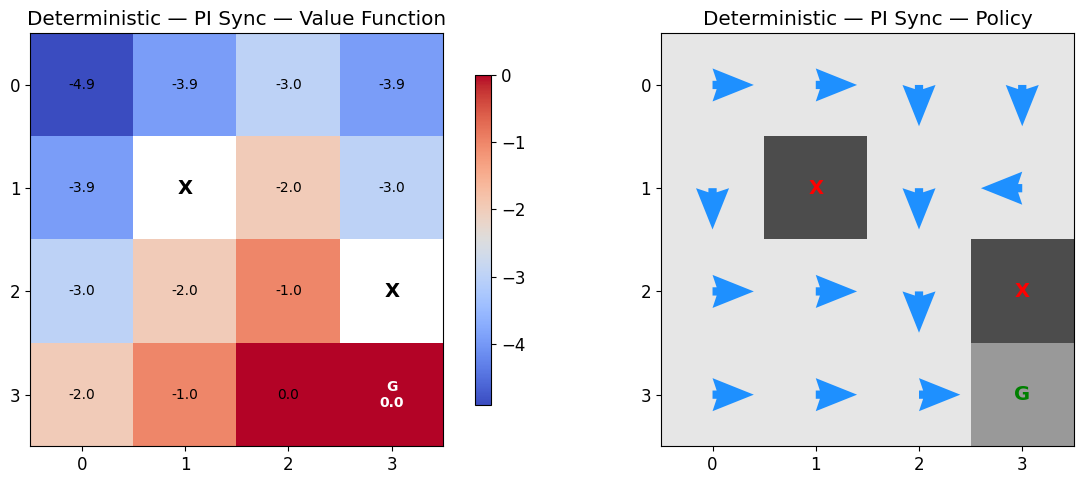

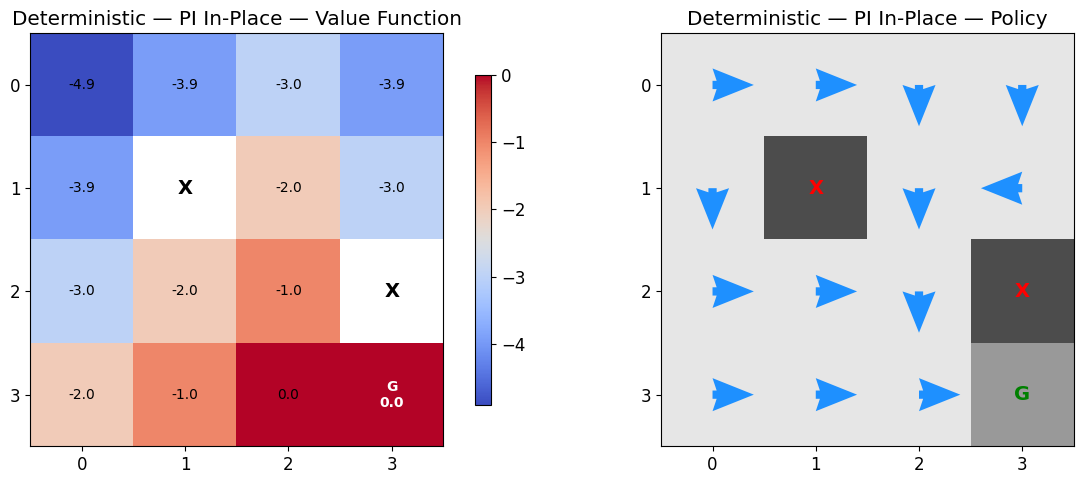

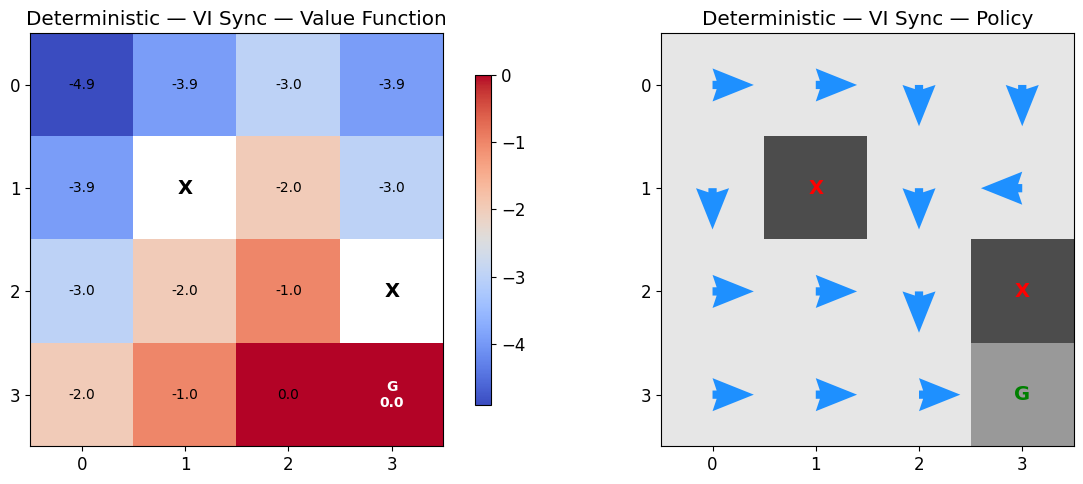

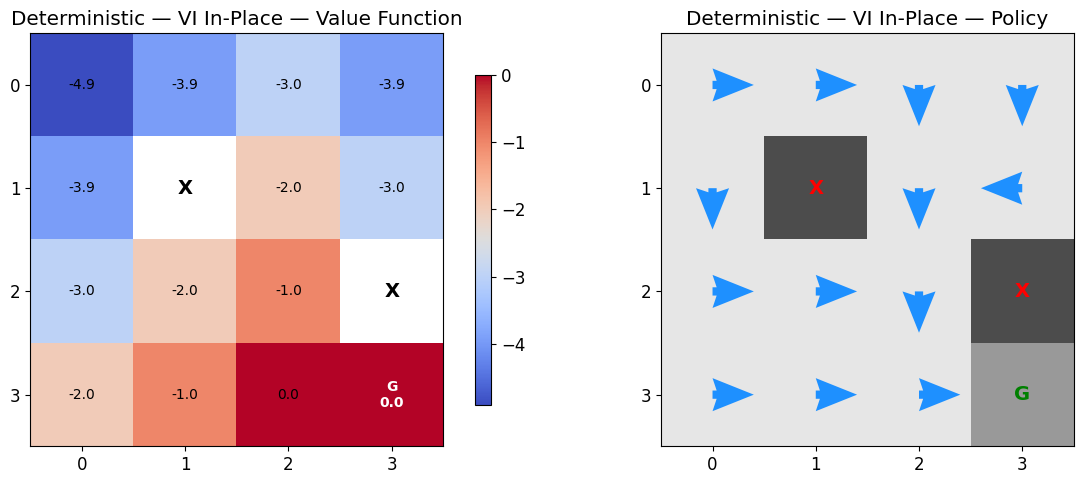

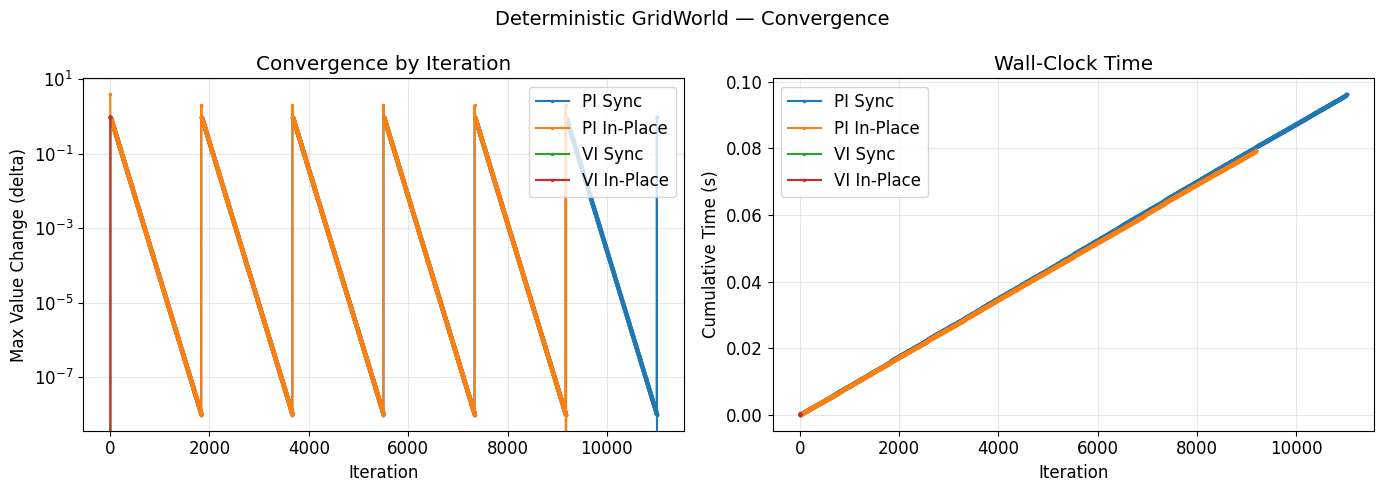

In [78]:
# Create deterministic 4x4 GridWorld
env_det = GridWorldEnv(
    grid_size=(4, 4),
    start=(0, 0),
    goals=[(3, 3)],
    obstacles=[(1, 1), (2, 3)],
    step_reward=-1.0,
    goal_reward=0.0,
    slip_prob=0.0,
)

print("Deterministic GridWorld layout:")
env_det.reset()
env_det.render()

# Run all four algorithms
print("Running Policy Iteration (Synchronous)...")
V_pi_sync, pol_pi_sync, hist_pi_sync = policy_iteration_sync(env_det, gamma=0.99)
print(f"  Converged in {len(hist_pi_sync['eval_sweeps'])} outer iterations, "
      f"{sum(hist_pi_sync['eval_sweeps'])} total eval sweeps, "
      f"{hist_pi_sync['total_time']:.4f}s")

print("Running Policy Iteration (In-Place)...")
V_pi_ip, pol_pi_ip, hist_pi_ip = policy_iteration_inplace(env_det, gamma=0.99)
print(f"  Converged in {len(hist_pi_ip['eval_sweeps'])} outer iterations, "
      f"{sum(hist_pi_ip['eval_sweeps'])} total eval sweeps, "
      f"{hist_pi_ip['total_time']:.4f}s")

print("Running Value Iteration (Synchronous)...")
V_vi_sync, pol_vi_sync, hist_vi_sync = value_iteration_sync(env_det, gamma=0.99)
print(f"  Converged in {len(hist_vi_sync['deltas'])} iterations, "
      f"{hist_vi_sync['total_time']:.4f}s")

print("Running Value Iteration (In-Place)...")
V_vi_ip, pol_vi_ip, hist_vi_ip = value_iteration_inplace(env_det, gamma=0.99)
print(f"  Converged in {len(hist_vi_ip['deltas'])} iterations, "
      f"{hist_vi_ip['total_time']:.4f}s")

# Visualize final results for each algorithm
for name, V, pol in [
    ("PI Sync", V_pi_sync, pol_pi_sync),
    ("PI In-Place", V_pi_ip, pol_pi_ip),
    ("VI Sync", V_vi_sync, pol_vi_sync),
    ("VI In-Place", V_vi_ip, pol_vi_ip),
]:
    plot_value_and_policy(V, pol, env_det, title=f"Deterministic — {name}")
    plt.show()

# Convergence comparison
convergence_results_det = {
    "PI Sync": hist_pi_sync,
    "PI In-Place": hist_pi_ip,
    "VI Sync": hist_vi_sync,
    "VI In-Place": hist_vi_ip,
}
plot_convergence(convergence_results_det, title="Deterministic GridWorld — Convergence")
plt.show()

## Experiment: Stochastic GridWorld
Test all four algorithm variants on a stochastic GridWorld.

### Steps:
- Configure GridWorld with 80% intended, 10% each perpendicular
- Run all four algorithm variants
- **Visualize**: heatmaps, policy arrows, convergence curves
- Compare results to deterministic case

Stochastic GridWorld layout (same grid, slip_prob=0.1):
A . . .
. X . .
. . . X
. . . G

Running Policy Iteration (Synchronous)...
  Converged in 5 outer iterations, 5637 total eval sweeps, 0.0860s
Running Policy Iteration (In-Place)...
  Converged in 4 outer iterations, 5092 total eval sweeps, 0.0760s
Running Value Iteration (Synchronous)...
  Converged in 36 iterations, 0.0032s
Running Value Iteration (In-Place)...
  Converged in 25 iterations, 0.0022s


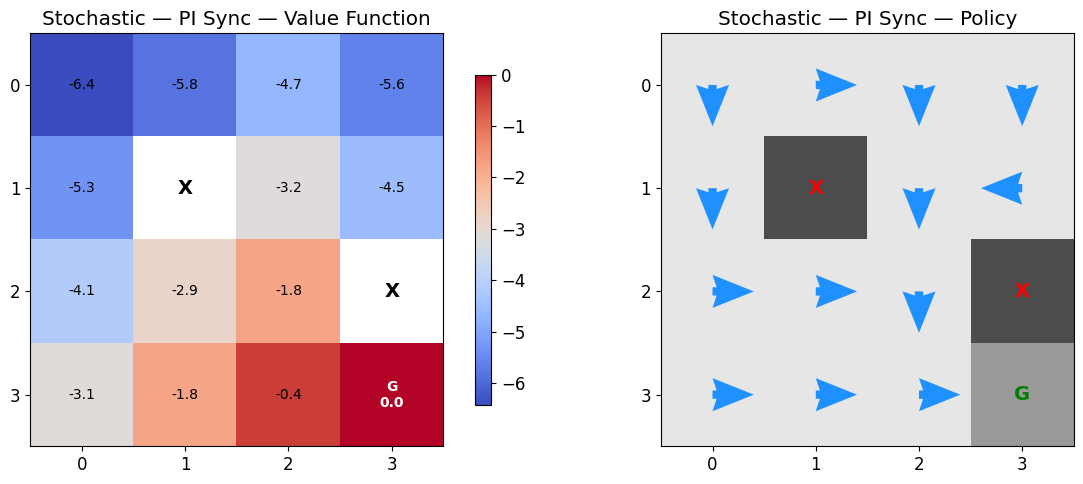

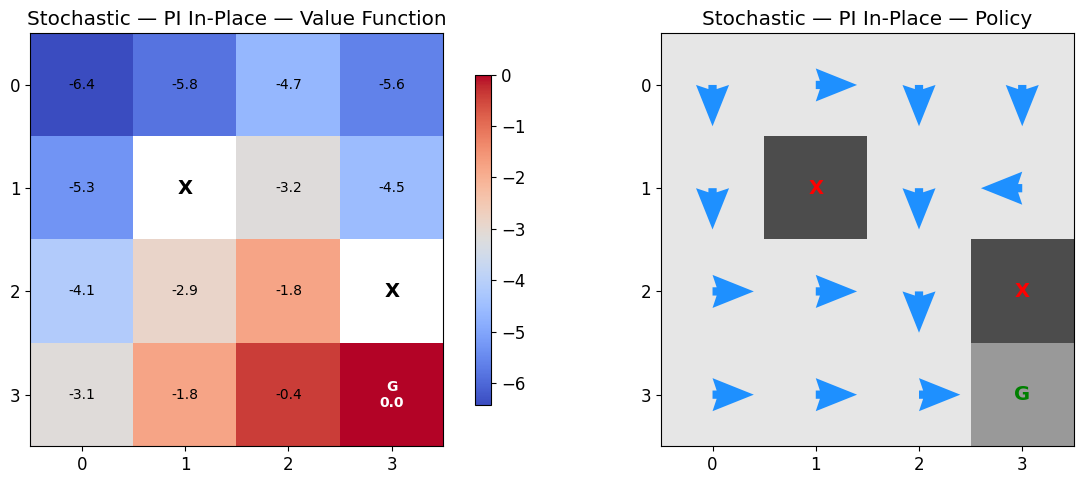

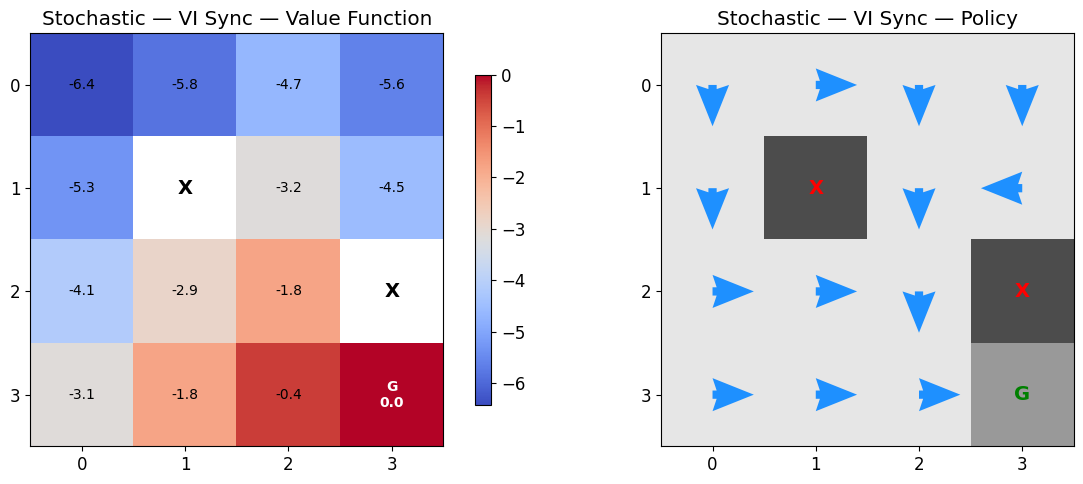

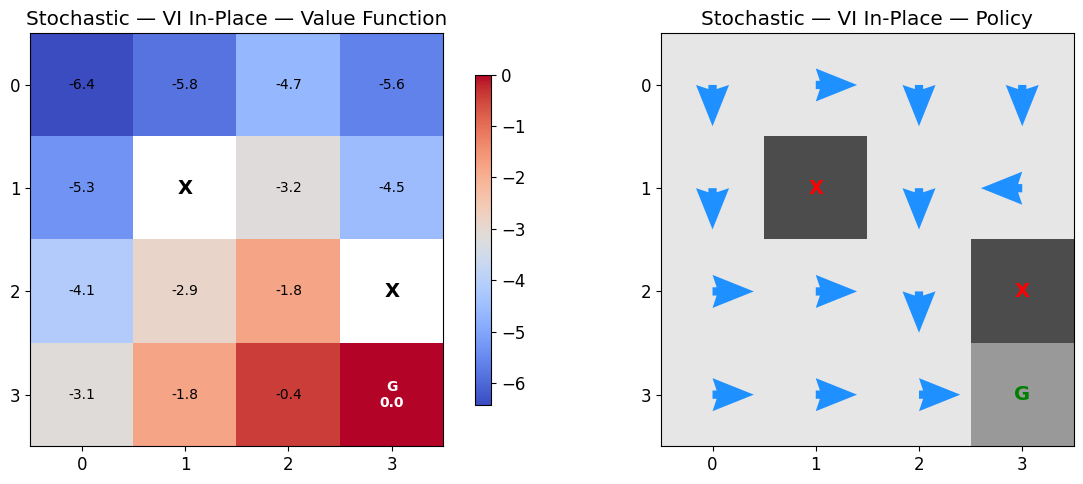

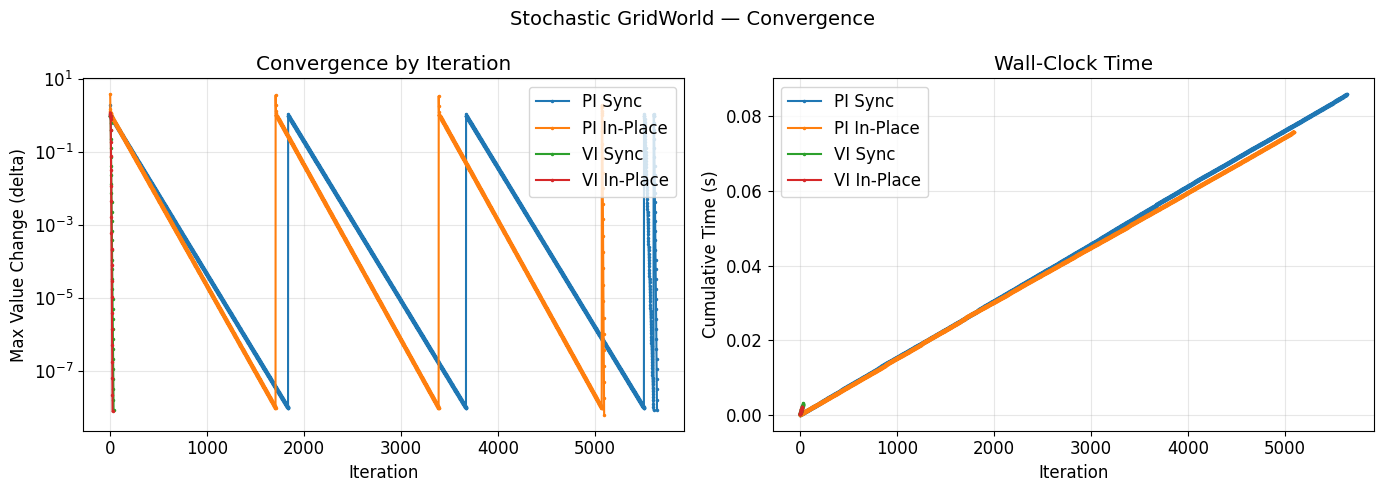

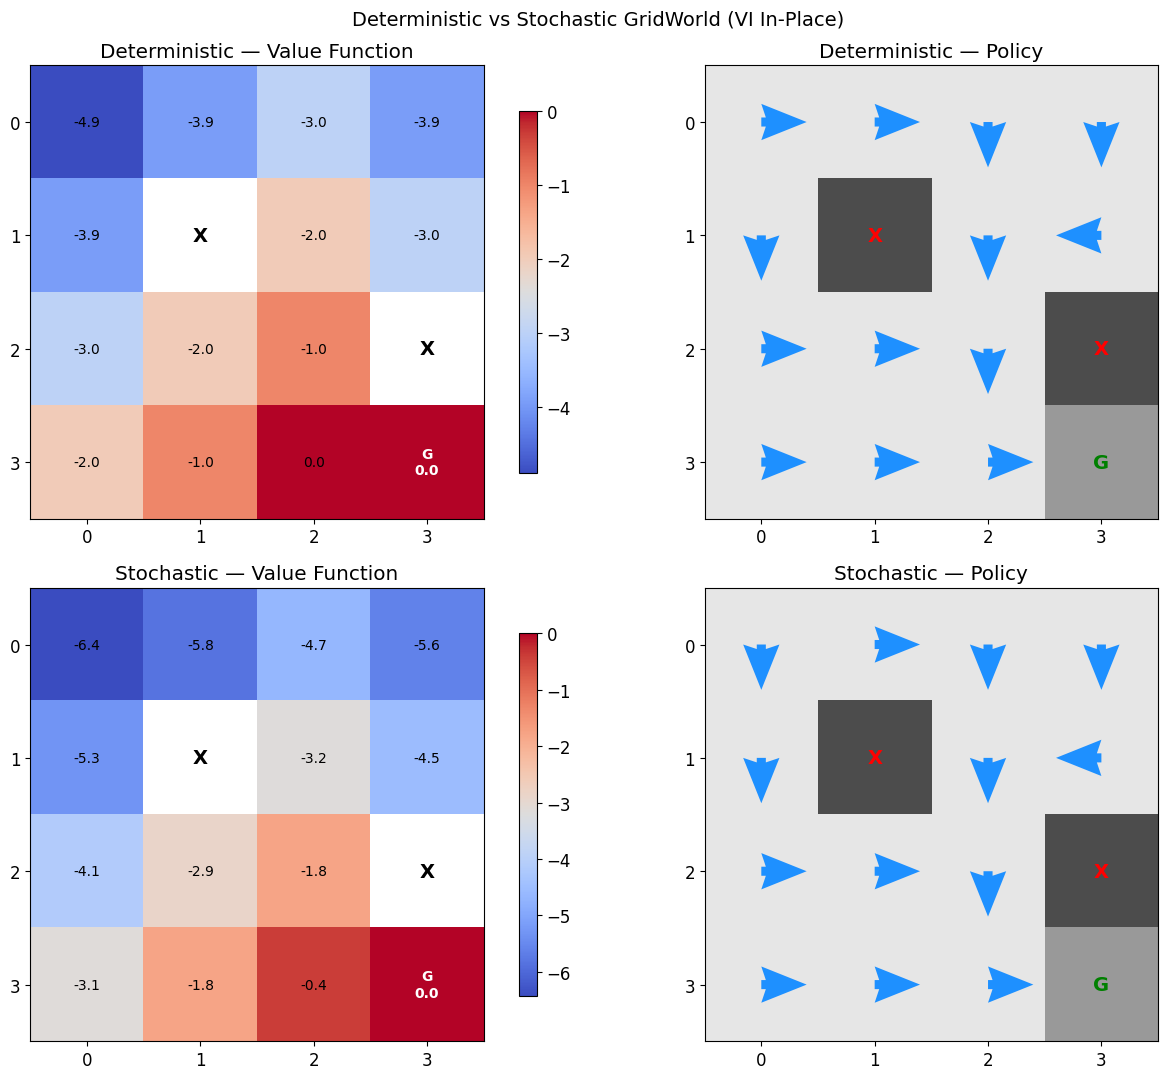

In [79]:
# Create stochastic 4x4 GridWorld (80% intended, 10% each perpendicular)
env_stoch = GridWorldEnv(
    grid_size=(4, 4),
    start=(0, 0),
    goals=[(3, 3)],
    obstacles=[(1, 1), (2, 3)],
    step_reward=-1.0,
    goal_reward=0.0,
    slip_prob=0.1,
)

print("Stochastic GridWorld layout (same grid, slip_prob=0.1):")
env_stoch.reset()
env_stoch.render()

# Run all four algorithms
print("Running Policy Iteration (Synchronous)...")
V_pi_sync_s, pol_pi_sync_s, hist_pi_sync_s = policy_iteration_sync(env_stoch, gamma=0.99)
print(f"  Converged in {len(hist_pi_sync_s['eval_sweeps'])} outer iterations, "
      f"{sum(hist_pi_sync_s['eval_sweeps'])} total eval sweeps, "
      f"{hist_pi_sync_s['total_time']:.4f}s")

print("Running Policy Iteration (In-Place)...")
V_pi_ip_s, pol_pi_ip_s, hist_pi_ip_s = policy_iteration_inplace(env_stoch, gamma=0.99)
print(f"  Converged in {len(hist_pi_ip_s['eval_sweeps'])} outer iterations, "
      f"{sum(hist_pi_ip_s['eval_sweeps'])} total eval sweeps, "
      f"{hist_pi_ip_s['total_time']:.4f}s")

print("Running Value Iteration (Synchronous)...")
V_vi_sync_s, pol_vi_sync_s, hist_vi_sync_s = value_iteration_sync(env_stoch, gamma=0.99)
print(f"  Converged in {len(hist_vi_sync_s['deltas'])} iterations, "
      f"{hist_vi_sync_s['total_time']:.4f}s")

print("Running Value Iteration (In-Place)...")
V_vi_ip_s, pol_vi_ip_s, hist_vi_ip_s = value_iteration_inplace(env_stoch, gamma=0.99)
print(f"  Converged in {len(hist_vi_ip_s['deltas'])} iterations, "
      f"{hist_vi_ip_s['total_time']:.4f}s")

# Visualize final results for each algorithm
for name, V, pol in [
    ("PI Sync", V_pi_sync_s, pol_pi_sync_s),
    ("PI In-Place", V_pi_ip_s, pol_pi_ip_s),
    ("VI Sync", V_vi_sync_s, pol_vi_sync_s),
    ("VI In-Place", V_vi_ip_s, pol_vi_ip_s),
]:
    plot_value_and_policy(V, pol, env_stoch, title=f"Stochastic — {name}")
    plt.show()

# Convergence comparison
convergence_results_stoch = {
    "PI Sync": hist_pi_sync_s,
    "PI In-Place": hist_pi_ip_s,
    "VI Sync": hist_vi_sync_s,
    "VI In-Place": hist_vi_ip_s,
}
plot_convergence(convergence_results_stoch, title="Stochastic GridWorld — Convergence")
plt.show()

# Side-by-side: deterministic vs stochastic (VI In-Place as representative)
fig, axes = plt.subplots(2, 2, figsize=(14, 11))
plot_value_function(V_vi_ip, env_det, ax=axes[0, 0], title="Deterministic — Value Function")
plot_policy(pol_vi_ip, env_det, ax=axes[0, 1], title="Deterministic — Policy")
plot_value_function(V_vi_ip_s, env_stoch, ax=axes[1, 0], title="Stochastic — Value Function")
plot_policy(pol_vi_ip_s, env_stoch, ax=axes[1, 1], title="Stochastic — Policy")
plt.suptitle("Deterministic vs Stochastic GridWorld (VI In-Place)", fontsize=14)
plt.tight_layout()
plt.show()

## Gymnasium FrozenLake-v1
Apply DP implementations to a standard Gymnasium environment.

### Steps:
- Load `FrozenLake-v1` (4x4 and/or 8x8)
- Access transition dynamics via `env.unwrapped.P`
- Run policy iteration and value iteration
- Visualize results and compare convergence

FrozenLake-v1 (4x4, is_slippery=True):
[[b'S' b'F' b'F' b'F']
 [b'F' b'H' b'F' b'H']
 [b'F' b'F' b'F' b'H']
 [b'H' b'F' b'F' b'G']]

Running Policy Iteration (Synchronous)...
  Converged in 7 outer iterations, 1426 total eval sweeps, 0.0204s
Running Policy Iteration (In-Place)...
  Converged in 7 outer iterations, 1147 total eval sweeps, 0.0162s
Running Value Iteration (Synchronous)...
  Converged in 438 iterations, 0.0342s
Running Value Iteration (In-Place)...
  Converged in 324 iterations, 0.0252s


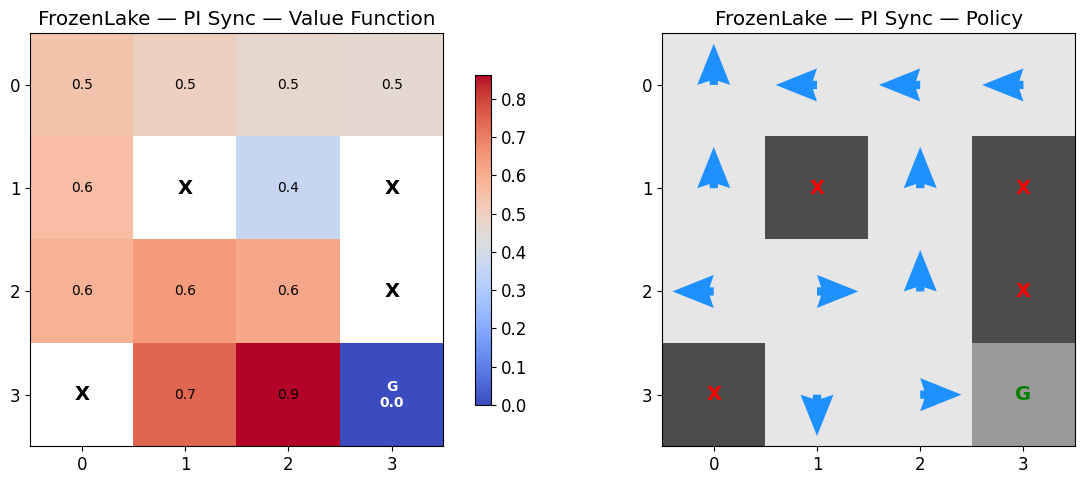

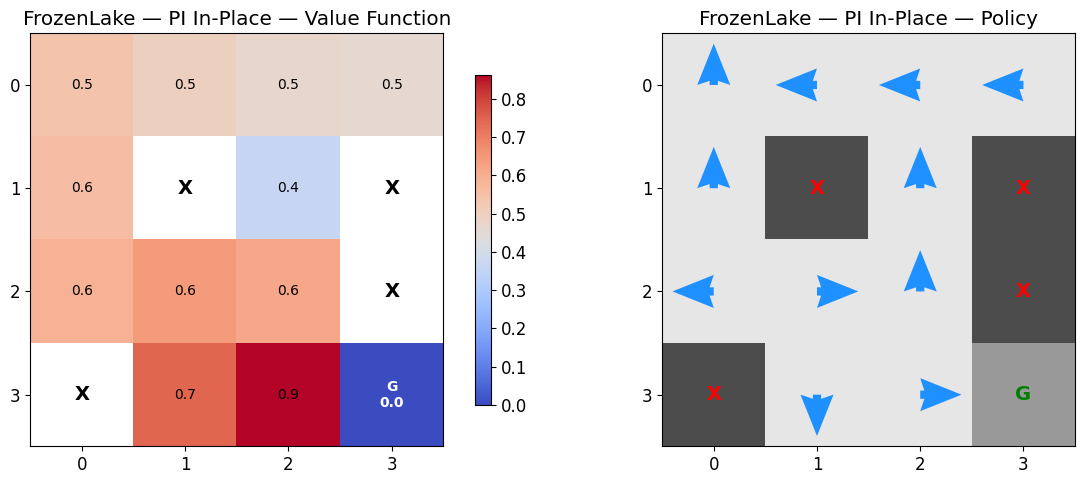

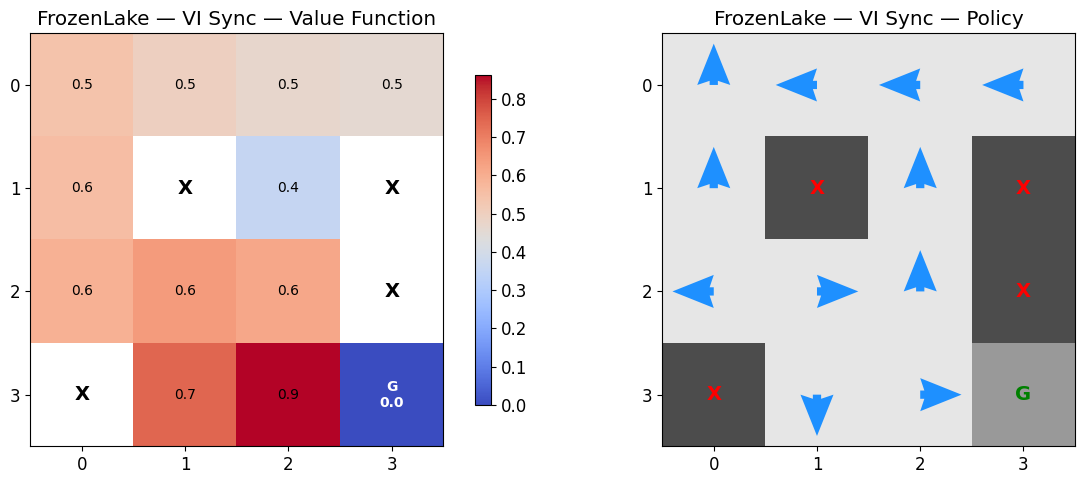

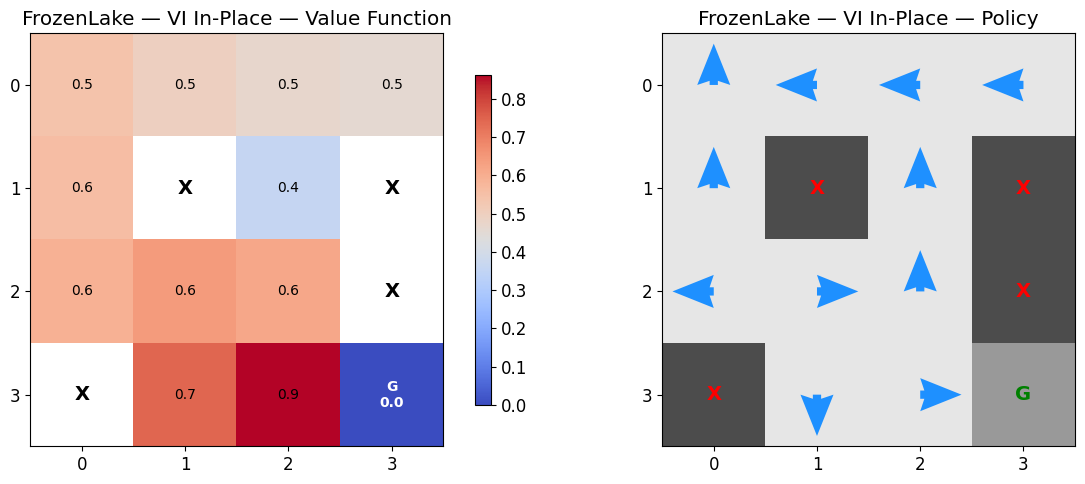

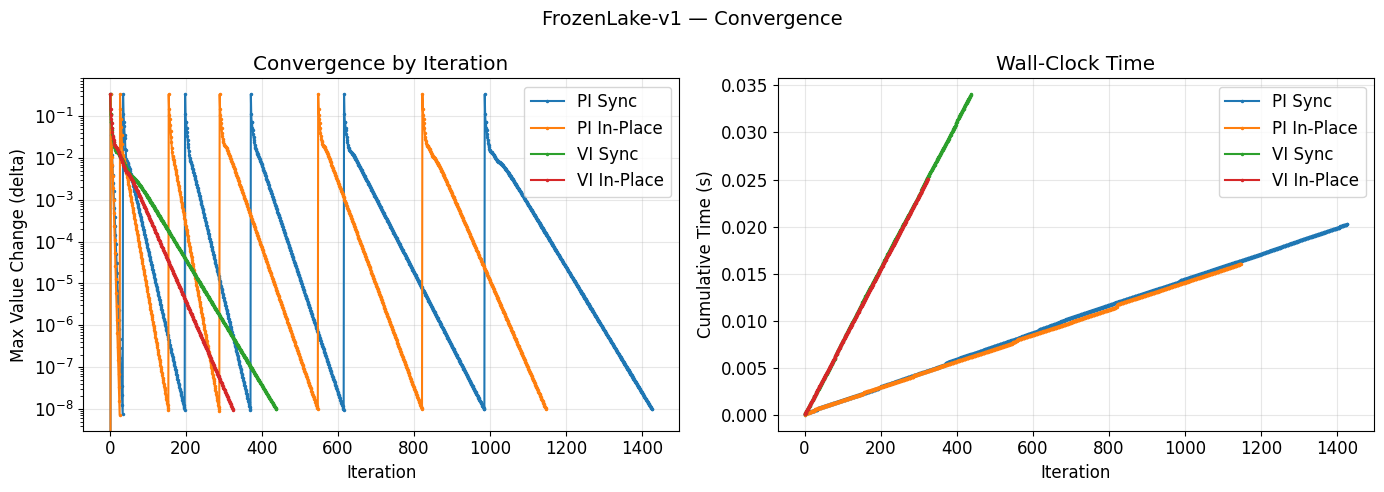

In [80]:
# Load FrozenLake-v1 and create a wrapper to work with our functions
fl_env_raw = gym.make("FrozenLake-v1", map_name="4x4", is_slippery=True)

class FrozenLakeWrapper:
    """Thin wrapper so FrozenLake works with our DP functions."""
    def __init__(self, env):
        self.env = env.unwrapped
        self.P = self.env.P
        self.n_states = self.env.observation_space.n
        self.action_space = self.env.action_space
        self.nrow = self.env.nrow
        self.ncol = self.env.ncol
        # FrozenLake: S=start, F=frozen, H=hole, G=goal
        self.desc = self.env.desc
        self.goals = []
        self.obstacles = []
        for r in range(self.nrow):
            for c in range(self.ncol):
                tile = self.desc[r, c].decode() if isinstance(self.desc[r, c], bytes) else self.desc[r, c]
                if tile == "G":
                    self.goals.append((r, c))
                elif tile == "H":
                    self.obstacles.append((r, c))

    def _state_to_pos(self, state):
        return divmod(state, self.ncol)

fl_env = FrozenLakeWrapper(fl_env_raw)

print("FrozenLake-v1 (4x4, is_slippery=True):")
print(fl_env_raw.unwrapped.desc)
print()

# Run all four algorithms
print("Running Policy Iteration (Synchronous)...")
V_fl_pi_sync, pol_fl_pi_sync, hist_fl_pi_sync = policy_iteration_sync(fl_env, gamma=0.99)
print(f"  Converged in {len(hist_fl_pi_sync['eval_sweeps'])} outer iterations, "
      f"{sum(hist_fl_pi_sync['eval_sweeps'])} total eval sweeps, "
      f"{hist_fl_pi_sync['total_time']:.4f}s")

print("Running Policy Iteration (In-Place)...")
V_fl_pi_ip, pol_fl_pi_ip, hist_fl_pi_ip = policy_iteration_inplace(fl_env, gamma=0.99)
print(f"  Converged in {len(hist_fl_pi_ip['eval_sweeps'])} outer iterations, "
      f"{sum(hist_fl_pi_ip['eval_sweeps'])} total eval sweeps, "
      f"{hist_fl_pi_ip['total_time']:.4f}s")

print("Running Value Iteration (Synchronous)...")
V_fl_vi_sync, pol_fl_vi_sync, hist_fl_vi_sync = value_iteration_sync(fl_env, gamma=0.99)
print(f"  Converged in {len(hist_fl_vi_sync['deltas'])} iterations, "
      f"{hist_fl_vi_sync['total_time']:.4f}s")

print("Running Value Iteration (In-Place)...")
V_fl_vi_ip, pol_fl_vi_ip, hist_fl_vi_ip = value_iteration_inplace(fl_env, gamma=0.99)
print(f"  Converged in {len(hist_fl_vi_ip['deltas'])} iterations, "
      f"{hist_fl_vi_ip['total_time']:.4f}s")

# Visualize final results
for name, V, pol in [
    ("PI Sync", V_fl_pi_sync, pol_fl_pi_sync),
    ("PI In-Place", V_fl_pi_ip, pol_fl_pi_ip),
    ("VI Sync", V_fl_vi_sync, pol_fl_vi_sync),
    ("VI In-Place", V_fl_vi_ip, pol_fl_vi_ip),
]:
    plot_value_and_policy(V, pol, fl_env, title=f"FrozenLake — {name}")
    plt.show()

# Convergence comparison
convergence_results_fl = {
    "PI Sync": hist_fl_pi_sync,
    "PI In-Place": hist_fl_pi_ip,
    "VI Sync": hist_fl_vi_sync,
    "VI In-Place": hist_fl_vi_ip,
}
plot_convergence(convergence_results_fl, title="FrozenLake-v1 — Convergence")
plt.show()

## Convergence Comparison & Analysis
Document which algorithm converges faster and why.

### Compare across all experiments:
- Number of iterations to convergence
- Wall-clock time
- Synchronous vs. in-place performance
- Policy iteration vs. value iteration
- Deterministic vs. stochastic environments

### Discussion points:
- Why does in-place typically converge faster?
- When is policy iteration preferred over value iteration (and vice versa)?
- How does stochasticity affect convergence?
- Generalized Policy Iteration (GPI) framework — how do these algorithms fit?

CONVERGENCE SUMMARY
            Environment   Algorithm  Total Sweeps/Iterations Time (s) Final Delta
Deterministic GridWorld     PI Sync                    11010   0.0963    0.00e+00
Deterministic GridWorld PI In-Place                     9182   0.0795    0.00e+00
Deterministic GridWorld     VI Sync                        6   0.0004    0.00e+00
Deterministic GridWorld VI In-Place                        6   0.0004    0.00e+00
   Stochastic GridWorld     PI Sync                     5637   0.0860    8.91e-09
   Stochastic GridWorld PI In-Place                     5092   0.0760    6.51e-09
   Stochastic GridWorld     VI Sync                       36   0.0032    8.91e-09
   Stochastic GridWorld VI In-Place                       25   0.0022    8.15e-09
          FrozenLake-v1     PI Sync                     1426   0.0204    9.73e-09
          FrozenLake-v1 PI In-Place                     1147   0.0162    9.87e-09
          FrozenLake-v1     VI Sync                      438   0.0342    9.77e

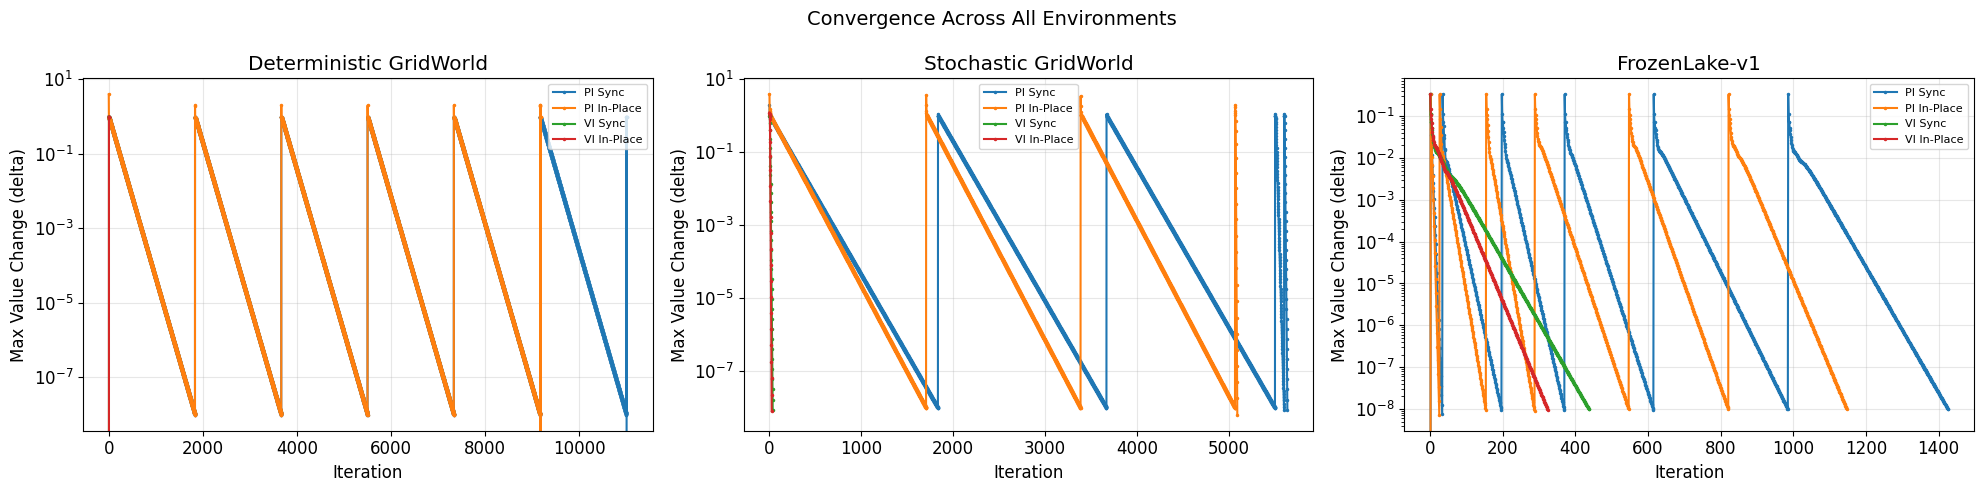

In [81]:
# Summary table across all environments
import pandas as pd

rows = []
for env_name, results in [
    ("Deterministic GridWorld", convergence_results_det),
    ("Stochastic GridWorld", convergence_results_stoch),
    ("FrozenLake-v1", convergence_results_fl),
]:
    for algo_name, hist in results.items():
        rows.append({
            "Environment": env_name,
            "Algorithm": algo_name,
            "Total Sweeps/Iterations": len(hist["deltas"]),
            "Time (s)": f"{hist['total_time']:.4f}" if 'total_time' in hist else f"{hist['times'][-1]:.4f}",
            "Final Delta": f"{hist['deltas'][-1]:.2e}",
        })

summary = pd.DataFrame(rows)
print("=" * 80)
print("CONVERGENCE SUMMARY")
print("=" * 80)
print(summary.to_string(index=False))
print()

# All three environments convergence side-by-side
fig, axes = plt.subplots(1, 3, figsize=(20, 5))
for ax, (env_name, results) in zip(axes, [
    ("Deterministic GridWorld", convergence_results_det),
    ("Stochastic GridWorld", convergence_results_stoch),
    ("FrozenLake-v1", convergence_results_fl),
]):
    for name, data in results.items():
        iterations = range(1, len(data["deltas"]) + 1)
        ax.plot(iterations, data["deltas"], label=name, marker=".", markersize=3)
    ax.set_yscale("log")
    ax.set_xlabel("Iteration")
    ax.set_ylabel("Max Value Change (delta)")
    ax.set_title(env_name)
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3)
plt.suptitle("Convergence Across All Environments", fontsize=14)
plt.tight_layout()
plt.show()

### Discussion

**In-place vs. Synchronous**: In-place updates typically converge in fewer iterations because each state immediately benefits from updates to earlier states in the same sweep. The effect is most pronounced when states have strong sequential dependencies (e.g., a corridor leading to the goal).

**Policy Iteration vs. Value Iteration**: Policy iteration requires fewer outer iterations (the policy stabilizes quickly), but each outer iteration runs a full policy evaluation to convergence — many inner sweeps. Value iteration does more total sweeps but each is cheaper (no inner loop). For small state spaces the difference is minor; for large ones, value iteration often wins on wall-clock time.

**Deterministic vs. Stochastic**: Stochastic environments generally require more iterations to converge because the value of each state depends on a weighted mix of neighbors, spreading information more slowly. The optimal policies become more conservative — avoiding edges where a slip could be costly.

**Generalized Policy Iteration (GPI)**: All of these algorithms are instances of GPI — the general idea of interleaving evaluation and improvement. Policy iteration does full evaluation before improving. Value iteration does a single evaluation sweep before improving. Any point on this spectrum converges, and the "right" tradeoff depends on the problem size and structure.

## Save Figures for Report

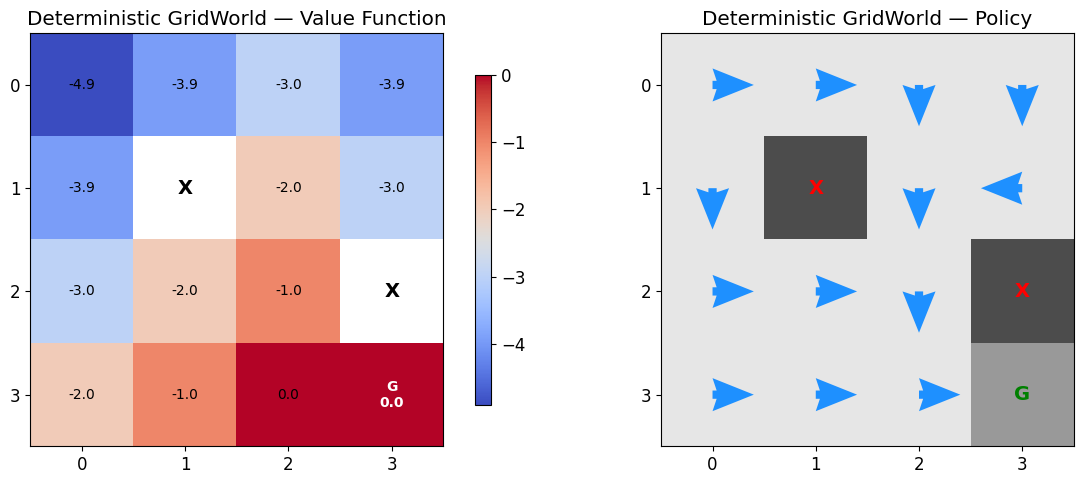

Saved: figures/deterministic_value_policy.png


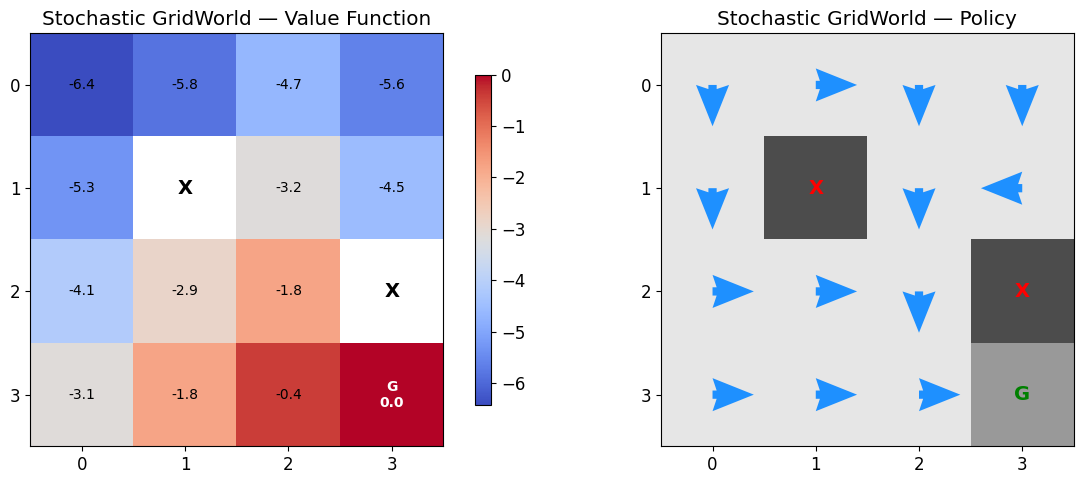

Saved: figures/stochastic_value_policy.png


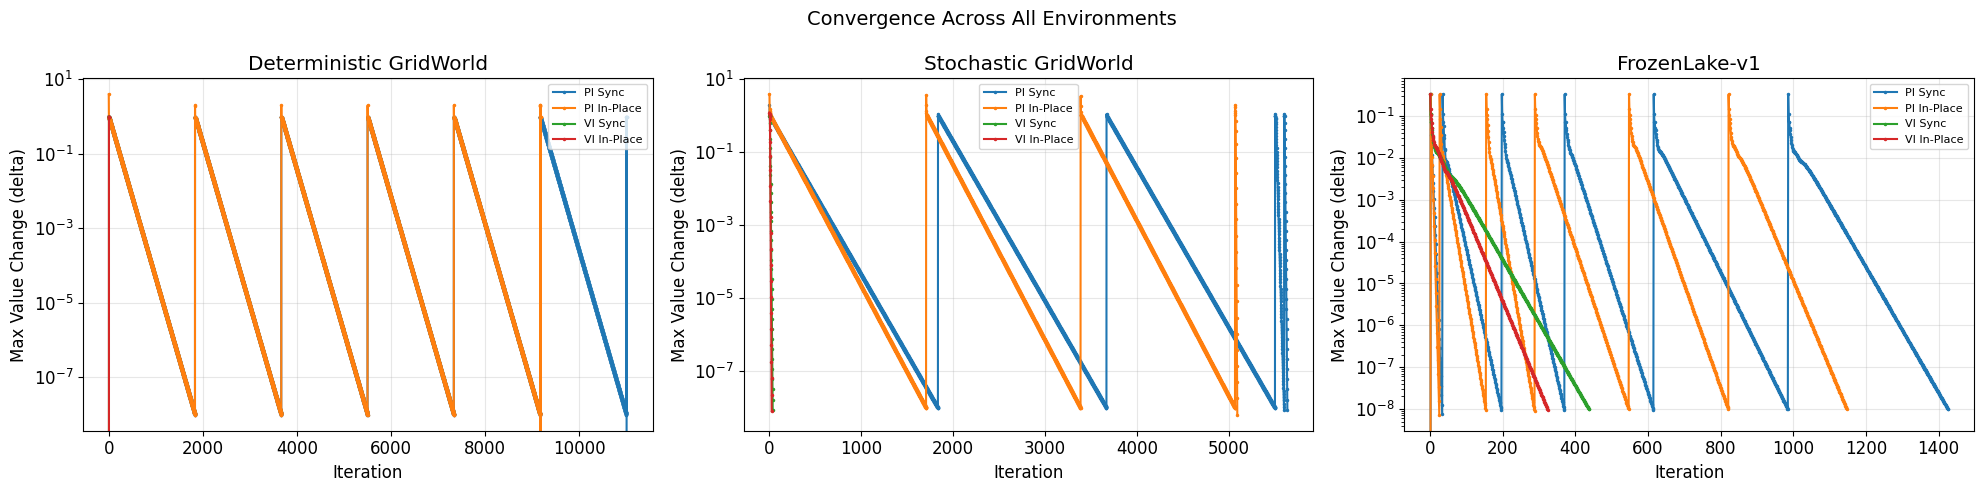

Saved: figures/convergence_comparison.png


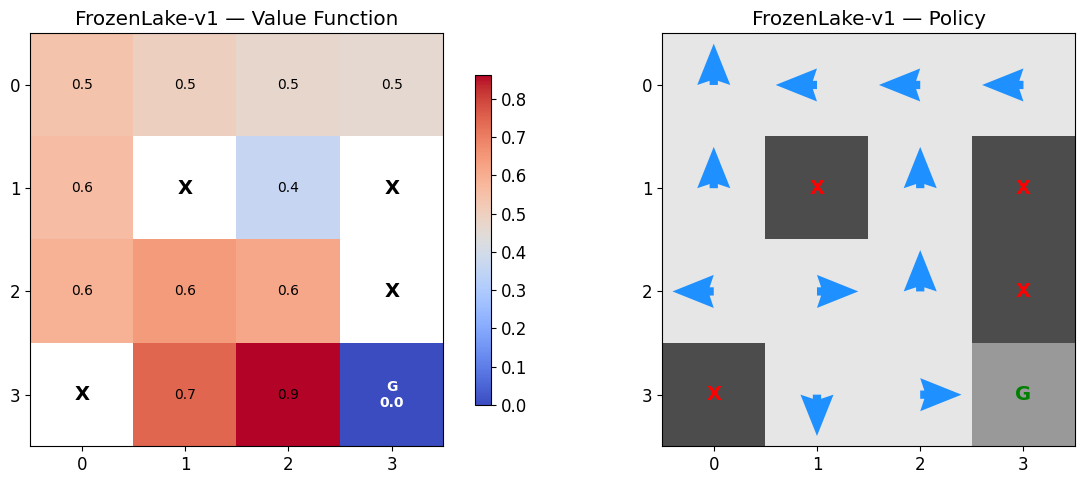

Saved: figures/frozenlake_value_policy.png


In [82]:
import os
os.makedirs("figures", exist_ok=True)

# Figure 1: Deterministic GridWorld — value function + policy (VI In-Place as representative)
fig = plot_value_and_policy(V_vi_ip, pol_vi_ip, env_det, title="Deterministic GridWorld")
fig.savefig("figures/deterministic_value_policy.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: figures/deterministic_value_policy.png")

# Figure 2: Stochastic GridWorld — value function + policy (VI In-Place)
fig = plot_value_and_policy(V_vi_ip_s, pol_vi_ip_s, env_stoch, title="Stochastic GridWorld")
fig.savefig("figures/stochastic_value_policy.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: figures/stochastic_value_policy.png")

# Figure 3: Convergence comparison across all environments
fig, axes = plt.subplots(1, 3, figsize=(20, 5))
for ax, (env_name, results) in zip(axes, [
    ("Deterministic GridWorld", convergence_results_det),
    ("Stochastic GridWorld", convergence_results_stoch),
    ("FrozenLake-v1", convergence_results_fl),
]):
    for name, data in results.items():
        iterations = range(1, len(data["deltas"]) + 1)
        ax.plot(iterations, data["deltas"], label=name, marker=".", markersize=3)
    ax.set_yscale("log")
    ax.set_xlabel("Iteration")
    ax.set_ylabel("Max Value Change (delta)")
    ax.set_title(env_name)
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3)
plt.suptitle("Convergence Across All Environments", fontsize=14)
plt.tight_layout()
fig.savefig("figures/convergence_comparison.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: figures/convergence_comparison.png")

# Figure 4: FrozenLake — value function + policy (VI In-Place)
fig = plot_value_and_policy(V_fl_vi_ip, pol_fl_vi_ip, fl_env, title="FrozenLake-v1")
fig.savefig("figures/frozenlake_value_policy.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: figures/frozenlake_value_policy.png")